# BERT Part A: Sentiment Classification of Food Delivery Reviews
### Pipeline:
1. Setup & upload dataset
2. Load & explore the reviews dataset
3. Tokenize text using BERT tokenizer
4. Fine-tune BERT for binary sentiment classification
5. Evaluate: accuracy, F1, confusion matrix, classification report
6. Inspect sample predictions

## Step 1  Install Dependencies & Upload Dataset

In [ ]:
!pip install transformers -q

In [ ]:
# Upload CLEAN_REVIEWS.csv from your computer
from google.colab import files
uploaded = files.upload()  # select CLEAN_REVIEWS.csv when prompted
print('Uploaded:', list(uploaded.keys()))

Saving CLEAN_REVIEWS.csv to CLEAN_REVIEWS.csv
Uploaded: ['CLEAN_REVIEWS.csv']


## Step 2  Imports

In [ ]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 120
OUTPUT_DIR = '/content/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')   # should print: cuda
print(f'Torch:  {torch.__version__}')
print('All libraries loaded.')

Device: cuda
Torch:  2.10.0+cu128
All libraries loaded.


## Step 3  Load & Explore Data

In [ ]:
df = pd.read_csv('CLEAN_REVIEWS.csv')

print(f'Shape:   {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
print('Class distribution:')
print(df['Sentiment'].value_counts().rename({0: 'Negative (0)', 1: 'Positive (1)'}).to_string())
print()
df.head()

Shape:   (20000, 6)
Columns: ['Review_ID', 'Restaurant', 'Rating', 'Sentiment', 'Review', 'clean']

Class distribution:
Sentiment
Positive (1)    10015
Negative (0)     9985



,Review_ID,Restaurant,Rating,Sentiment,Review,clean
0,1,McDonalds,2,0,Highly recommended Nuggets... if you hate good...,highly recommended nuggets.. if you hate good ...
1,2,McDonalds,5,0,The Fries was overcooked and the portion size ...,the fries was overcooked and the portion size ...
2,3,McDonalds,5,1,"To be honest, The Big Mac was excellent and th...","to be honest, the big mac was excellent and th..."
3,4,McDonalds,4,0,"To be honest, The Nuggets was bland and the pa...","to be honest, the nuggets was bland and the pa..."
4,5,McDonalds,5,1,"Honestly, The McChicken was incredible and the...","honestly, the mcchicken was incredible and the..."


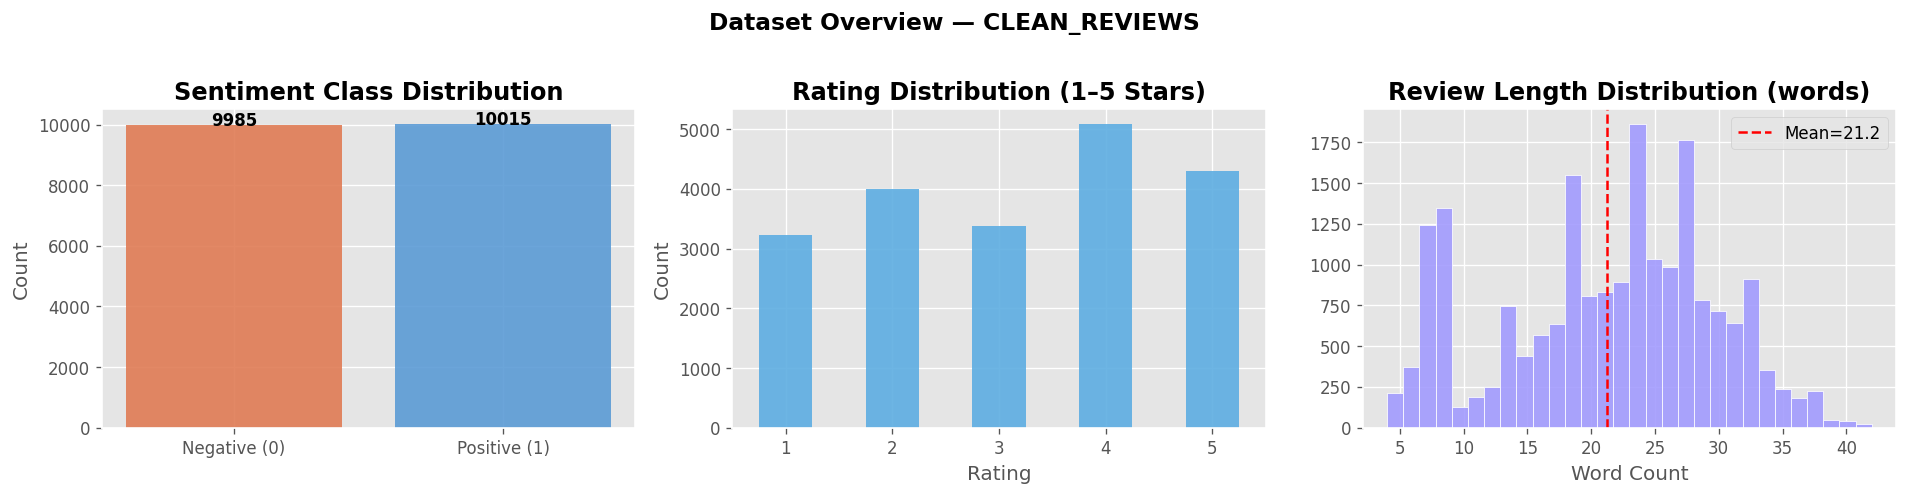

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sentiment distribution
counts = df['Sentiment'].value_counts().sort_index()
axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values, color=['#E07B54', '#5B9BD5'], alpha=0.9)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Sentiment Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Rating distribution
df['Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#5DADE2', alpha=0.9, rot=0)
axes[1].set_title('Rating Distribution (1–5 Stars)', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

# Review length distribution
df['review_len'] = df['clean'].astype(str).apply(lambda x: len(x.split()))
axes[2].hist(df['review_len'], bins=30, color='#A29BFE', alpha=0.9, edgecolor='white')
axes[2].axvline(df['review_len'].mean(), color='red', linestyle='--', label=f"Mean={df['review_len'].mean():.1f}")
axes[2].set_title('Review Length Distribution (words)', fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].legend()

plt.suptitle('Dataset Overview — CLEAN_REVIEWS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bert_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4  Train / Validation / Test Split

In [ ]:
df = df.dropna(subset=['clean']).reset_index(drop=True)

# Remove duplicate reviews to prevent data leakage across train/test sets
before = len(df)
df = df.drop_duplicates(subset=['clean']).reset_index(drop=True)
after = len(df)
print(f'Removed {before - after} duplicate reviews ({before} → {after} unique)')

texts  = df['clean'].astype(str).tolist()
labels = df['Sentiment'].tolist()

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Verify no leakage
overlap = set(X_train) & set(X_test)
print(f'Train/test overlap after dedup: {len(overlap)} (should be 0)')
print()
print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')
print(f'Train positives: {sum(y_train)/len(y_train)*100:.1f}%')
print(f'Val   positives: {sum(y_val)/len(y_val)*100:.1f}%')
print(f'Test  positives: {sum(y_test)/len(y_test)*100:.1f}%')

Removed 2652 duplicate reviews (20000 → 17348 unique)
Train/test overlap after dedup: 0 (should be 0)

Train: 12,143  |  Val: 2,602  |  Test: 2,603
Train positives: 57.7%
Val   positives: 57.6%
Test  positives: 57.7%


## Step 5  Tokenization & Dataset

In [ ]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 64
BATCH_SIZE = 32

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = ReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = ReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = ReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased
Train batches: 380  |  Val: 82  |  Test: 82


## Step 6  Load BERT Model

In [ ]:
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model:            {MODEL_NAME}')
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print(f'Device:           {DEVICE}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model:            bert-base-uncased
Total params:     109,483,778
Trainable params: 109,483,778
Device:           cuda


## Step 7  Fine-tune BERT

In [ ]:
EPOCHS = 3
LR     = 2e-5

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels_batch   = batch['label'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_batch)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_preds, all_labels

history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for batch in train_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels_batch   = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_batch)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += outputs.loss.item()

    avg_train = train_loss / len(train_loader)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}')

Epoch 1/3 | Train Loss: 0.0987 | Val Loss: 0.0002 | Val Acc: 1.0000 | Val F1: 1.0000
Epoch 2/3 | Train Loss: 0.0002 | Val Loss: 0.0001 | Val Acc: 1.0000 | Val F1: 1.0000
Epoch 3/3 | Train Loss: 0.0001 | Val Loss: 0.0001 | Val Acc: 1.0000 | Val F1: 1.0000


## Step 8  Training Curves

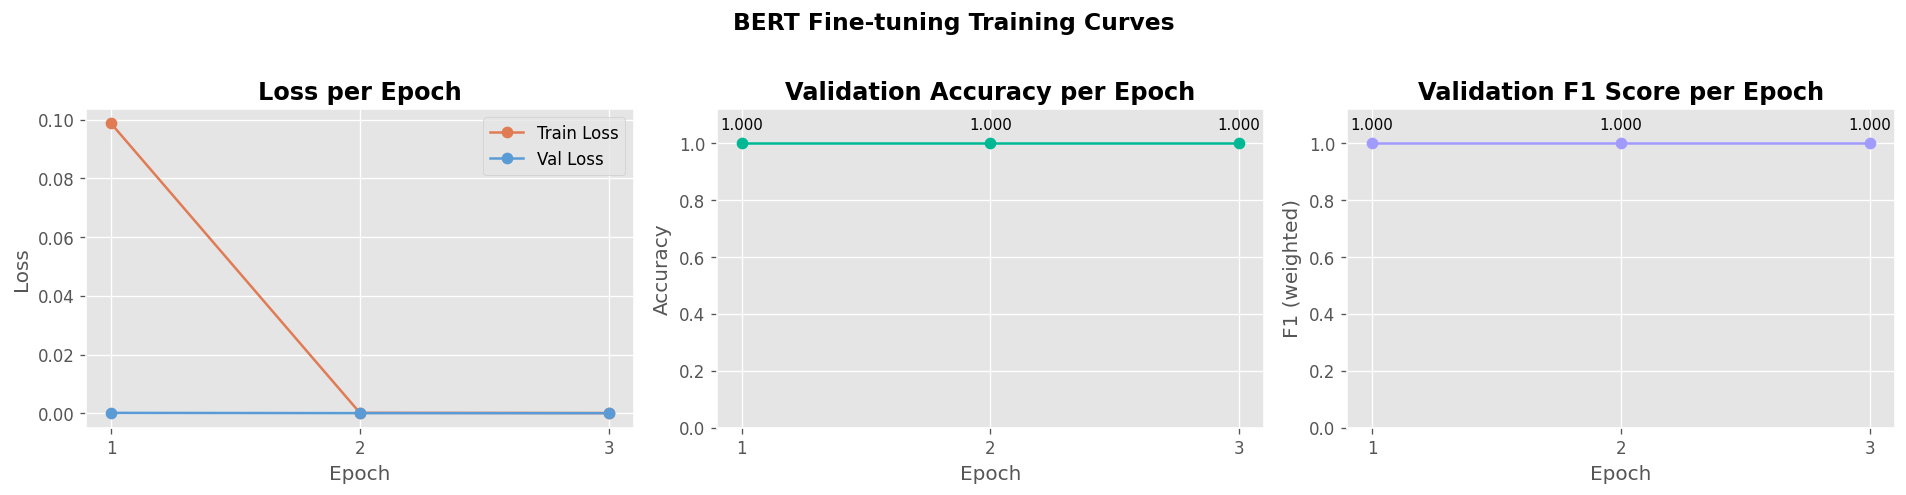

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = history['epoch']

axes[0].plot(epochs, history['train_loss'], 'o-', color='#E07B54', label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   'o-', color='#5B9BD5', label='Val Loss')
axes[0].set_title('Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].set_xticks(epochs)

axes[1].plot(epochs, history['val_acc'], 'o-', color='#00B894')
axes[1].set_title('Validation Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.12); axes[1].set_xticks(epochs)
for x, y in zip(epochs, history['val_acc']):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

axes[2].plot(epochs, history['val_f1'], 'o-', color='#A29BFE')
axes[2].set_title('Validation F1 Score per Epoch', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 (weighted)')
axes[2].set_ylim(0, 1.12); axes[2].set_xticks(epochs)
for x, y in zip(epochs, history['val_f1']):
    axes[2].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle('BERT Fine-tuning Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9  Evaluate on Test Set

In [17]:
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader)

print('=' * 50)
print('TEST SET RESULTS')
print('=' * 50)
print(f'Loss:     {test_loss:.4f}')
print(f'Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'F1 Score: {test_f1:.4f}  (weighted)')
print()
print('Classification Report:')
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))

TEST SET RESULTS
Loss:     0.0001
Accuracy: 1.0000  (100.00%)
F1 Score: 1.0000  (weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1102
    Positive       1.00      1.00      1.00      1501

    accuracy                           1.00      2603
   macro avg       1.00      1.00      1.00      2603
weighted avg       1.00      1.00      1.00      2603



## Step 10  Confusion Matrix

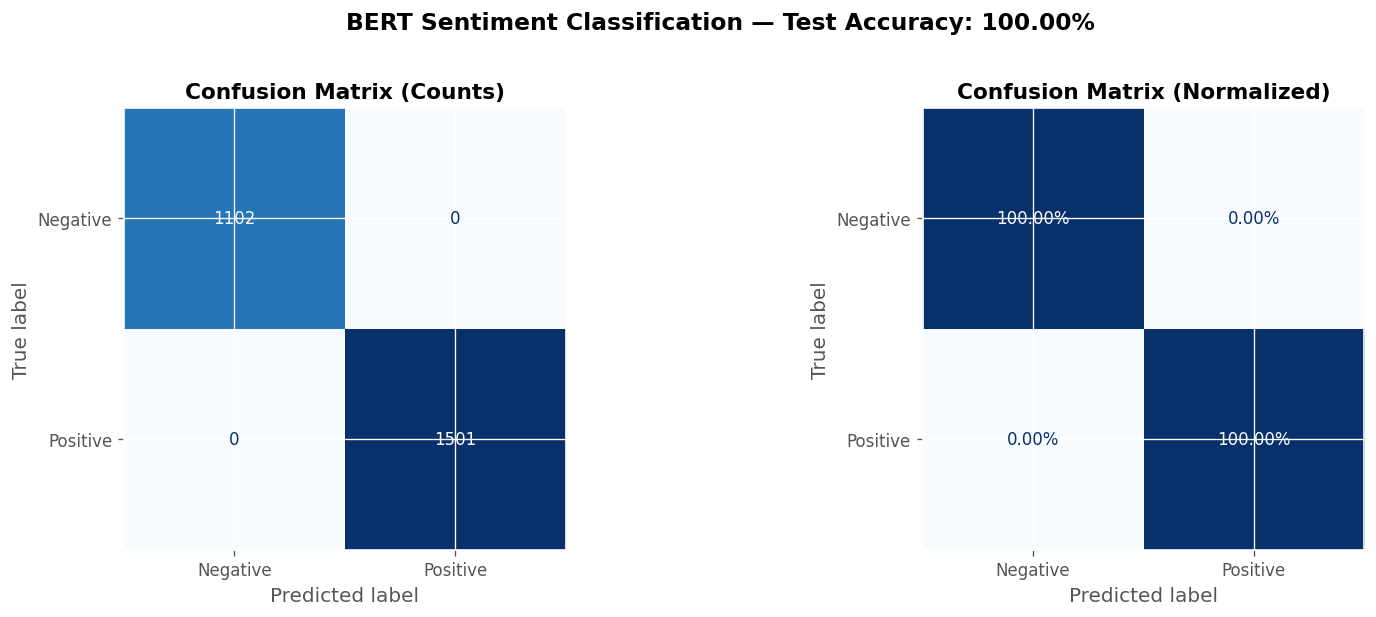

In [18]:
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold', fontsize=13)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Negative', 'Positive'])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
disp_norm.im_.set_clim(0, 1)
for text in disp_norm.text_.ravel():
    text.set_text(f"{float(text.get_text()):.2%}")
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold', fontsize=13)

plt.suptitle(f'BERT Sentiment Classification — Test Accuracy: {test_acc:.2%}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11  Sample Predictions

In [19]:
label_map = {0: 'Negative', 1: 'Positive'}

results_df = pd.DataFrame({
    'Review':    X_test,
    'True':      [label_map[l] for l in y_test],
    'Predicted': [label_map[p] for p in test_preds],
})
results_df['Correct'] = results_df['True'] == results_df['Predicted']

print('=== 5 Correct Predictions ===')
for _, row in results_df[results_df['Correct']].sample(5, random_state=42).iterrows():
    print(f'  [{row["True"]}] "{row["Review"][:80]}..."')

print()
print('=== 5 Incorrect Predictions ===')
wrong = results_df[~results_df['Correct']]
if len(wrong) >= 5:
    for _, row in wrong.sample(5, random_state=42).iterrows():
        print(f'  [True: {row["True"]} | Pred: {row["Predicted"]}] "{row["Review"][:80]}..."')
else:
    print(f'  Only {len(wrong)} incorrect predictions found — model is performing very well!')

print(f'\nOverall: {results_df["Correct"].sum():,} correct out of {len(results_df):,} ({results_df["Correct"].mean()*100:.2f}%)')

=== 5 Correct Predictions ===
  [Negative] "honestly, the fries was bad and the portion size was very bad the fries did not ..."
  [Negative] "honestly, the nuggets was horrible and the price was very bad the nuggets did no..."
  [Positive] "the mcchicken was outstanding and the price was really good the mcchicken felt f..."
  [Positive] "the mozzarella sticks was fresh and the quality was really good better than last..."
  [Negative] "the koshary was tasteless and the taste was very bad worse than expected never a..."

=== 5 Incorrect Predictions ===
  Only 0 incorrect predictions found — model is performing very well!

Overall: 2,603 correct out of 2,603 (100.00%)


## Step 12  Key Insights

In [20]:
best_epoch = history['val_acc'].index(max(history['val_acc'])) + 1
tn, fp, fn, tp = cm.ravel()

print('=' * 60)
print('BERT PART A — KEY INSIGHTS')
print('=' * 60)
print(f'\n1. MODEL:     bert-base-uncased, fine-tuned for {EPOCHS} epochs')
print(f'   Max length: {MAX_LEN} tokens | Batch size: {BATCH_SIZE}')
print(f'\n2. BEST EPOCH: {best_epoch} — Val Accuracy: {max(history["val_acc"]):.4f}, Val F1: {max(history["val_f1"]):.4f}')
print(f'\n3. TEST PERFORMANCE:')
print(f'   Accuracy: {test_acc*100:.2f}%')
print(f'   F1 Score: {test_f1:.4f} (weighted)')
print(f'\n4. CONFUSION MATRIX BREAKDOWN:')
print(f'   True Negatives:  {tn:,}  (correctly identified as Negative)')
print(f'   True Positives:  {tp:,}  (correctly identified as Positive)')
print(f'   False Positives: {fp:,}  (Negative mislabeled as Positive)')
print(f'   False Negatives: {fn:,}  (Positive mislabeled as Negative)')
print(f'\n5. CONCLUSION: BERT successfully distinguishes positive from')
print(f'   negative food delivery reviews using semantic understanding')
print(f'   of customer language, outperforming simple keyword-based approaches.')
print('=' * 60)

BERT PART A — KEY INSIGHTS

1. MODEL:     bert-base-uncased, fine-tuned for 3 epochs
   Max length: 64 tokens | Batch size: 32

2. BEST EPOCH: 1 — Val Accuracy: 1.0000, Val F1: 1.0000

3. TEST PERFORMANCE:
   Accuracy: 100.00%
   F1 Score: 1.0000 (weighted)

4. CONFUSION MATRIX BREAKDOWN:
   True Negatives:  1,102  (correctly identified as Negative)
   True Positives:  1,501  (correctly identified as Positive)
   False Positives: 0  (Negative mislabeled as Positive)
   False Negatives: 0  (Positive mislabeled as Negative)

5. CONCLUSION: BERT successfully distinguishes positive from
   negative food delivery reviews using semantic understanding
   of customer language, outperforming simple keyword-based approaches.
